## Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sales_data = pd.read_csv("train.csv")
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
sales_data.shape

(9800, 18)

In [5]:
# Preprocessing
sales_data["Order Date"] = pd.to_datetime(sales_data["Order Date"], format="%d/%m/%Y")
sales_data["Ship Date"] = pd.to_datetime(sales_data["Ship Date"], format="%d/%m/%Y")

sales_data['Year'] = sales_data['Order Date'].dt.year
sales_data['Month'] = sales_data['Order Date'].dt.month
sales_data['Week Number'] = sales_data['Order Date'].dt.isocalendar().week
sales_data['Day of Week'] = sales_data['Order Date'].dt.day_name()
sales_data['Quarter'] = sales_data['Order Date'].dt.quarter

# Function to extract season
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else: return "Post-Monsoon"
sales_data['Season'] = sales_data['Month'].apply(get_season)

print("Missing Values:\n", sales_data.isnull().sum(),sep="")
print("\nDuplicates Count:", sales_data.duplicated().sum())

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

Duplicates Count: 0


In [6]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [33]:
df_time = sales_data.set_index('Order Date')

# Aggregating daily sales into weekly totals
weekly_sales = df_time['Sales'].resample('W').sum().reset_index()

# Aggregating daily sales into monthly totals (ME-month end frequency) 
monthly_sales = df_time['Sales'].resample('ME').sum().reset_index()


## EDA

In [8]:
category_revenue = sales_data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(f"Highest generating category: {category_revenue.idxmax()}\n")
print(category_revenue)

Highest generating category: Technology

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [9]:
# Total sales per region per year
yearly_region_sales = sales_data.groupby(['Region', 'Year'])['Sales'].sum().unstack()

# Year-over-year percentage change
growth_rates = yearly_region_sales.pct_change(axis=1).dropna(axis=1)

# The region with the lowest standard deviation in its growth rate is the most consistent.
consistency_score = growth_rates.std(axis=1).sort_values()
most_consistent = consistency_score.idxmin()
print(f"Most consistent region: {most_consistent}\n")
print("Standard Deviation of Growth Rates:\n", consistency_score, sep="")

Most consistent region: East

Standard Deviation of Growth Rates:
Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64


In [10]:
df = sales_data.copy()
df['Processing Time'] = (df['Ship Date'] - df['Order Date']).dt.days
# Overall average
overall_avg = df['Processing Time'].mean()
print(f"Overall average processing time: {overall_avg:.2f} days")

# Average by region
regional_avg = df.groupby('Region')['Processing Time'].mean().sort_values()
print("\nAverage processing time by region:\n", regional_avg, sep="")

Overall average processing time: 3.96 days

Average processing time by region:
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Processing Time, dtype: float64


In [11]:
# Total sales for each month across all years
monthly_avg_across_years = sales_data.groupby('Month')['Sales'].mean().sort_values(ascending=False)

print("Average Sales by Month (checking for month spikes):")
print(monthly_avg_across_years)

Average Sales by Month (checking for month spikes):
Month
3     290.549393
1     257.627403
10    246.596162
11    241.657496
12    232.619515
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     207.432269
2     199.902745
Name: Sales, dtype: float64


## Time series analysis

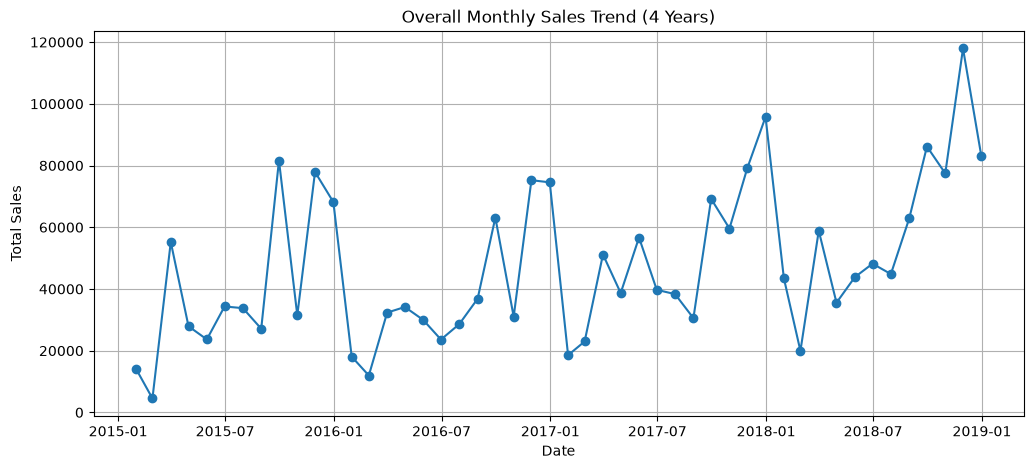

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Clear out the broken numeric index to recover columns
monthly_sales = monthly_sales.reset_index()
monthly_sales['Order Date'] = pd.to_datetime(monthly_sales['Order Date'])
monthly_sales.set_index('Order Date', inplace=True)
# Plot overall monthly sales trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales['Sales'], marker='o', linestyle='-')
plt.title('Overall Monthly Sales Trend (4 Years)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

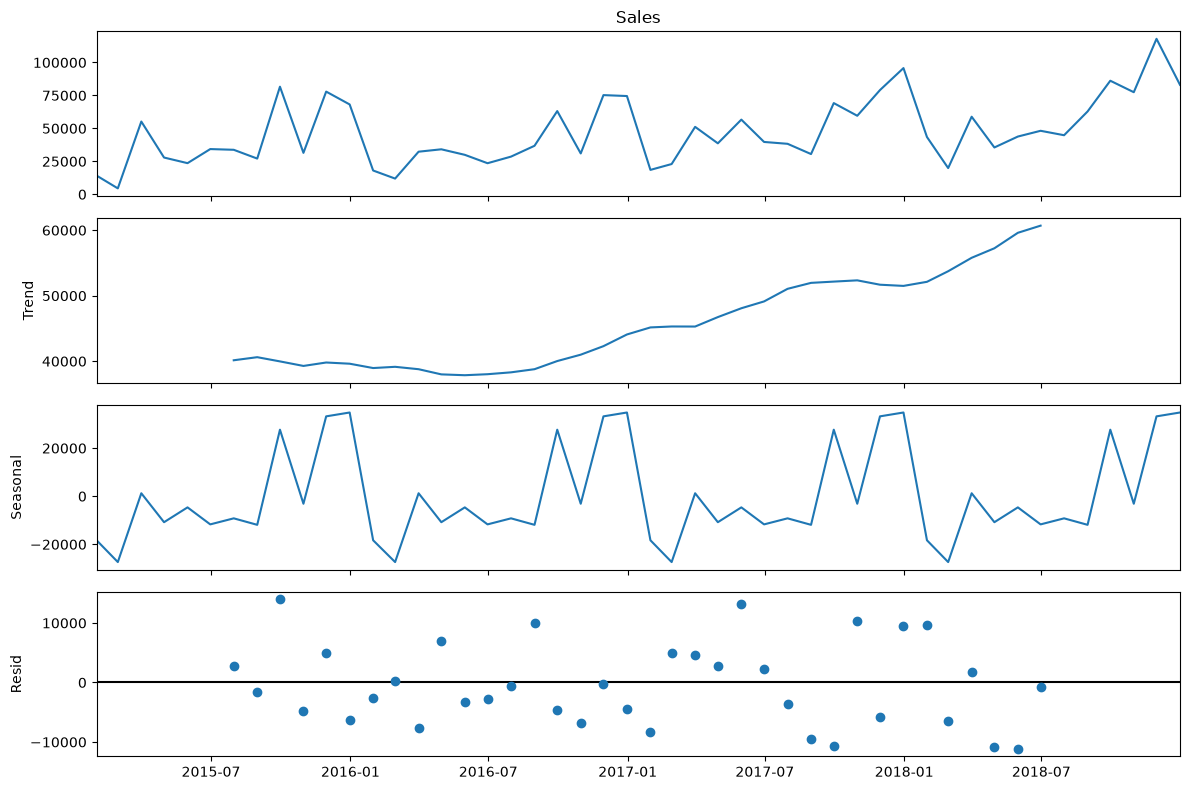

In [13]:
# Time Series Decomposition
# I use period=12 because the data is monthly and expect a yearly seasonal cycle
decomposition = seasonal_decompose(monthly_sales['Sales'], model='additive', period=12)

# Plot all 4 components clearly on one figure
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

**Insights**
- **Overall Upward Trend**: The trend line shows a steady, long-term increase in sales starting around mid-2016 and continuing through 2018.
- **Strong Seasonality**: Seasonality is very strong and highly predictable, featuring massive, identical recurring spikes and drops at the exact same intervals each year.
- **Peak Residual Noise**: The highest residual noise occurs around late 2015-07, 2016-07, and mid-to-late 2017, where individual data points deviate by more than 10,000 units from the baseline.

In [14]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna())
    
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    if result[1] <= 0.05:
        print("Conclusion: Strong evidence against the null hypothesis, data is stationary.")
    else:
        print("Conclusion: Weak evidence against null hypothesis, data is non-stationary.")

# Test on the original monthly sales
adf_test(monthly_sales['Sales'], title='Original Monthly Sales')

Augmented Dickey-Fuller Test: Original Monthly Sales
ADF Statistic: -4.4161
p-value: 0.0003
Conclusion: Strong evidence against the null hypothesis, data is stationary.


- **Stationarity**: A time series is stationary if its statistical properties like its average (mean) and how much it swings around that average (variance) do not change over time. If the sales are consistently growing year over year (an upward trend), the average is changing, which means the series is non-stationary.
- The ADF test checks for this using hypothesis testing.
  - Null Hypothesis: The series is non-stationary.
  - Alternative Hypothesis: The series is stationary.
  - If the p-value is less than 0.05, we reject the null hypothesis and consider the data stationary.
- As we can see the test clearly shows that data is stationary

## Sales Forecasting

#### Base Models

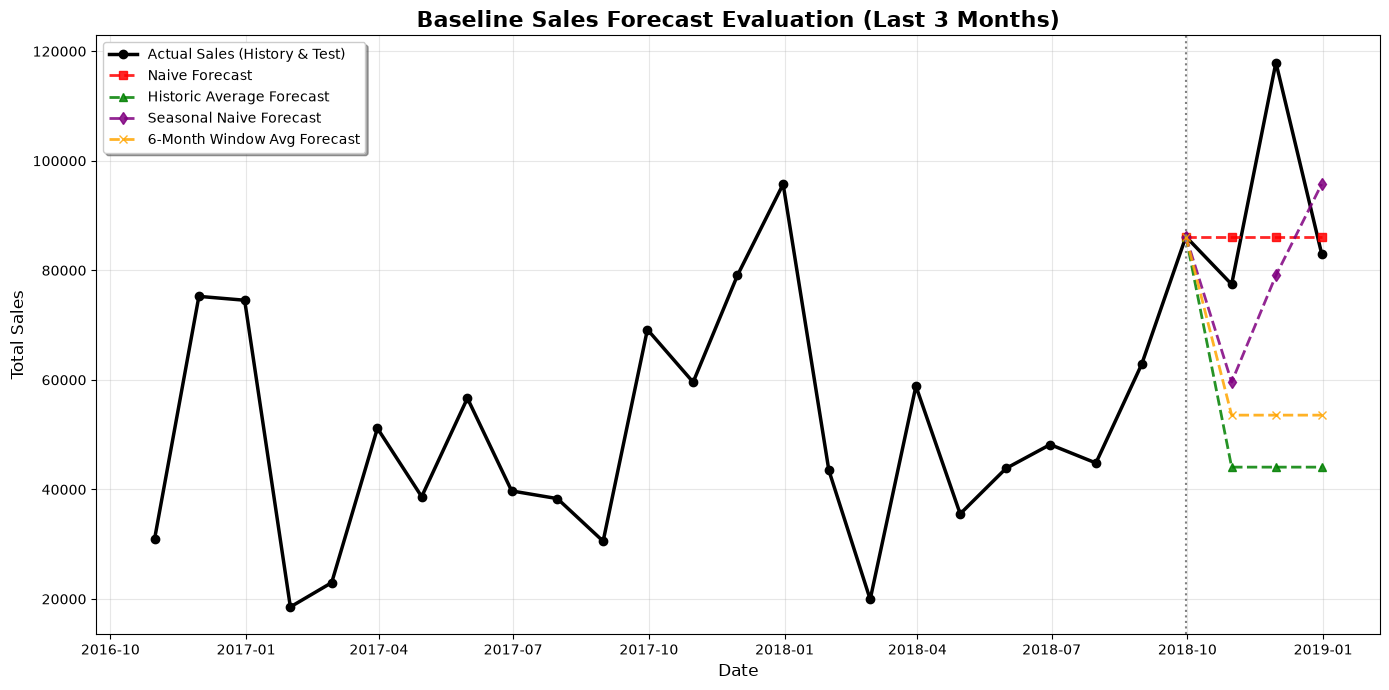

In [15]:
# Setup Forecast Horizon
forecast_steps = 3
train_history = monthly_sales.iloc[:-forecast_steps]
actual_sales = monthly_sales['Sales'].iloc[-forecast_steps:].values
forecast_dates = monthly_sales.index[-forecast_steps:]
last_date = monthly_sales.index[-1]

# Naive Forecast (Last observed value carried forward)
last_value = train_history['Sales'].iloc[-1]
naive_forecast = [last_value] * forecast_steps

# Historic Average (Mean of all time)
historic_mean = train_history['Sales'].mean()
historic_avg_forecast = [historic_mean] * forecast_steps

# Seasonal Naive (Values from exactly 12 months prior)
# We grab the 3 months starting from exactly one year before our forecast window
start_idx = -12
end_idx = start_idx + forecast_steps
if end_idx == 0:
    seasonal_naive_forecast = train_history['Sales'].iloc[start_idx:].values
else:
    seasonal_naive_forecast = train_history['Sales'].iloc[start_idx:end_idx].values

# Window Average (6-Month Moving Average)
window_size = 6
window_mean = train_history['Sales'].iloc[-window_size:].mean()
window_avg_forecast = [window_mean] * forecast_steps

# Combining into a Forecast DataFrame
baselines_df = pd.DataFrame({
    'Naive': naive_forecast,
    'Historic Average': historic_avg_forecast,
    'Seasonal Naive': seasonal_naive_forecast,
    '6-Month Window Avg': window_avg_forecast
}, index=forecast_dates)

plt.figure(figsize=(14, 7))
# 1. Combine historical context and true validation actuals into one continuous black series
full_actual_series = pd.concat([train_history['Sales'].iloc[-24:], monthly_sales['Sales'].iloc[-forecast_steps:]])
plt.plot(full_actual_series.index, full_actual_series, label='Actual Sales (History & Test)', color='black', linewidth=2.5, marker='o')

# 2. Plot baseline predictions extending from the end of the training history
colors = ['red', 'green', 'purple', 'orange']
markers = ['s', '^', 'd', 'x']

# The last date of training history serves as the visual anchor for predictions
anchor_date = train_history.index[-1]
anchor_value = train_history['Sales'].iloc[-1]

for col, color, marker in zip(baselines_df.columns, colors, markers):
    plot_idx = [anchor_date] + list(baselines_df.index)
    plot_vals = [anchor_value] + list(baselines_df[col])
    
    plt.plot(plot_idx, plot_vals, label=f'{col} Forecast', color=color, linestyle='--', marker=marker, linewidth=2, alpha=0.85)

# 3. Formatting and presentation
plt.title('Baseline Sales Forecast Evaluation (Last 3 Months)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)

# Add a visual vertical divider to mark the start of the backtesting forecast window
plt.axvline(x=anchor_date, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')

plt.tight_layout()
plt.show()


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

metrics_dict = {'Model': [], 'MAE': [], 'RMSE': [], 'MAPE (%)': []}

for col in baselines_df.columns:
    y_pred = baselines_df[col].values
    
    # Compute metrics
    mae = mean_absolute_error(actual_sales, y_pred)
    rmse = np.sqrt(mean_squared_error(actual_sales, y_pred))
    mape = mean_absolute_percentage_error(actual_sales, y_pred) * 100
    
    # Store rounded outputs
    metrics_dict['Model'].append(col)
    metrics_dict['MAE'].append(round(mae, 2))
    metrics_dict['RMSE'].append(round(rmse, 2))
    metrics_dict['MAPE (%)'].append(round(mape, 2))

# Convert to clean DataFrame table
metrics_df = pd.DataFrame(metrics_dict).set_index('Model')
print("Model Metrics (Last 3 Months Validation)")
print(metrics_df)

Model Metrics (Last 3 Months Validation)
                         MAE      RMSE  MAPE (%)
Model                                           
Naive               14537.51  19112.18     13.98
Historic Average    48736.22  51925.30     50.89
Seasonal Naive      23148.50  25766.12     23.78
6-Month Window Avg  39243.15  43139.80     40.31


Naive model performed best among the baseline models

#### SARIMA

In [17]:
import pmdarima as pm
# Using auto_arima to find the best ARIMA and SARIMA parameters for our monthly sales data

arima_model = pm.auto_arima(
    monthly_sales['Sales'], 
    seasonal=False,          # Explicitly turn OFF seasonality
    start_p=0, max_p=3, 
    start_q=0, max_q=3, 
    trace=True,              # Prints the search progress
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True       
)

sarima_model = pm.auto_arima(
    monthly_sales['Sales'], 
    seasonal=True,           # Explicitly turn ON seasonality
    m=12,                    # 12 months in a seasonal cycle
    start_p=0, max_p=3, 
    start_q=0, max_q=3, 
    D=1,                     # Enforce seasonal differencing
    trace=True,         
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True       
)

# Comparing AIC scores
arima_aic = arima_model.aic()
sarima_aic = sarima_model.aic()

print("\n--- Model Comparison (AIC Scores) ---")
print(f"Non-Seasonal ARIMA AIC: {arima_aic:.2f}")
print(f"Seasonal SARIMA AIC:    {sarima_aic:.2f}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1096.560, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1089.579, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1084.886, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1094.708, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1086.890, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1087.498, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1087.606, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1083.594, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1084.585, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1084.690, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1088.071, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1086.217, Time=0.12 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 0.871 seconds
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=78

I have used auto_arima stepwise search to minimize the AIC score, resulting in the optimal order $(p, d, q) \times (P, D, Q, 12)$. I have run two seperate auto_arima searches to compare a non-seasonal ARIMA model against a seasonal SARIMA model to mathematically prove whether factoring in seasonality actually improves our forecast.

Since the AIC score of SARIMA is lesser, it performs better than the AIRMA model. The data contains significant seasonality.

In [18]:
best_order = arima_model.order
best_sarima_order = sarima_model.order
best_seasonal = sarima_model.seasonal_order
print(f"Best ARIMA order (p,d,q): {best_order}")
print(f"Best SARIMA order (p,d,q) x (P,D,Q,m): {best_sarima_order}x{best_seasonal}")


Best ARIMA order (p,d,q): (0, 1, 1)
Best SARIMA order (p,d,q) x (P,D,Q,m): (1, 0, 1)x(0, 1, 1, 12)


In [59]:
# Imporoving the model using cross-validation
from pmdarima.model_selection import RollingForecastCV, cross_val_score
cv = RollingForecastCV(h=12, step=6, initial=24)
cv_scores = cross_val_score(sarima_model, monthly_sales['Sales'], scoring='mean_squared_error', cv=cv)
print(f"CV RMSE Scores: {np.sqrt(cv_scores)}")
print(f"Mean CV RMSE: {np.sqrt(np.mean(cv_scores))}")

CV RMSE Scores: [21075.02111535 12000.90225322 14026.5146689 ]
Mean CV RMSE: 16175.303023029628


In [60]:
sarima_model.fit(monthly_sales['Sales'])
sarima_forecast, sarima_conf_int = sarima_model.predict(n_periods=3, return_conf_int=True)
print("3-Month Sales Forecast:\n", sarima_forecast,sep="")
print("\nConfidence Intervals:\n", sarima_conf_int, sep="")

3-Month Sales Forecast:
2019-01-31    49686.016698
2019-02-28    36069.711531
2019-03-31    70458.335018
Freq: ME, dtype: float64

Confidence Intervals:
[[24311.41539881 75060.61799729]
 [10539.83176976 61599.59129298]
 [44882.8850233  96033.78501289]]


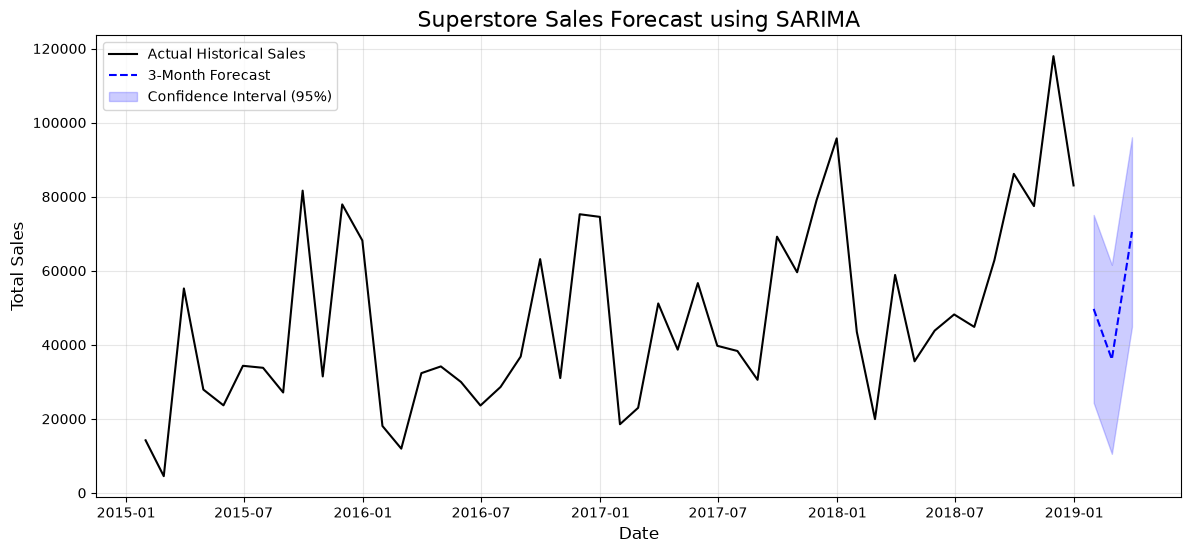

In [20]:
# Visualizing the SARIMA Forecast with Confidence Intervals
forecast_index = pd.date_range(
    start=monthly_sales.index[-1] + pd.offsets.MonthEnd(1), 
    periods=forecast_steps, 
    freq='ME'
)
predicted_mean_alt = pd.Series(sarima_forecast, index=forecast_index)
confidence_intervals_alt = pd.DataFrame(sarima_conf_int, index=forecast_index, columns=['Lower', 'Upper'])

plt.figure(figsize=(14, 6))

# Plot historical actual sales
plt.plot(monthly_sales.index, monthly_sales['Sales'], label='Actual Historical Sales', color='black')

# Plot the forecasted values
plt.plot(predicted_mean_alt.index, predicted_mean_alt, label='3-Month Forecast', color='blue', linestyle='--')

# Shade the confidence intervals
plt.fill_between(
    confidence_intervals_alt.index,
    confidence_intervals_alt.iloc[:, 0], # Lower bound
    confidence_intervals_alt.iloc[:, 1], # Upper bound
    color='blue', alpha=0.2, 
    label='Confidence Interval (95%)'
)

plt.title('Superstore Sales Forecast using SARIMA', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

#### FB Prophet

In [21]:
# Handling Outliers by observing the prophet sales forecast plot
# weekly_sales.at[11, 'Sales'] = np.nan
# weekly_sales.at[125, 'Sales'] = np.nan
# weekly_sales.at[168, 'Sales'] = np.nan

In [ ]:
# Assuming 'weekly_sales' is your DataFrame from Task 1
prophet_df = weekly_sales.copy()

# Rename columns to meet Prophet's strict requirements
prophet_df.columns = ['ds', 'y']

# Ensuring 'ds' is a proper datetime object
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

print(prophet_df.head())

          ds         y
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914


In [23]:
from prophet import Prophet

# Initialize the model with strategic parameters
m = Prophet(
    seasonality_mode='multiplicative', # Better for retail growth
    yearly_seasonality=True,           
    weekly_seasonality=True,
    daily_seasonality=False,           # Turning off daily as we don't have hourly data
    changepoint_prior_scale=0.05,      # sensitivity to trend changes
    seasonality_prior_scale=1.0        # sensitivity to seasonal changes(Lowering smoothness the curve)
)
# Let's add US holidays to the model to account for potential sales spikes during these periods
m.add_country_holidays(country_name='US')  # Adding US holidays to the model

# Fit the model to the historical data
m.fit(prophet_df)

12:10:50 - cmdstanpy - INFO - Chain [1] start processing
12:10:51 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
# Performing a grid search to find the best hyperparameters for Prophet
import itertools
from prophet.diagnostics import cross_validation, performance_metrics
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.1, 1.0, 10.0]
}

# Generate all combinations of hyperparameters
keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
rmses = []

for params in param_combinations:
    # Initialize a clean model with current hyperparameters
    m = Prophet(**params)
    m.add_country_holidays(country_name='US')
    m.fit(prophet_df)
    # Simulate forecasts every 90 days, predicting 90 days out
    df_cv = cross_validation(
        m, 
        initial='730 days',   # Size of the first training window
        period='180 days',    # Distance between cutoff dates
        horizon='365 days',   # How far into the future to forecast
        parallel="processes"  # Speeds up computation using multiprocessing
    )
    # Calculate the RMSE for the current parameter combination
    df_p = performance_metrics(df_cv)
    rmses.append(df_p['rmse'].values[0])

# Find the best hyperparameters based on the lowest RMSE
tuning_results = pd.DataFrame(param_combinations)
tuning_results['rmse'] = rmses

best_params = param_combinations[tuning_results['rmse'].idxmin()]
print(f"Optimal Parameters: {best_params}")

12:10:51 - cmdstanpy - INFO - Chain [1] start processing
12:10:51 - cmdstanpy - INFO - Chain [1] done processing
12:10:58 - cmdstanpy - INFO - Chain [1] start processing
12:10:58 - cmdstanpy - INFO - Chain [1] done processing
12:11:04 - cmdstanpy - INFO - Chain [1] start processing
12:11:04 - cmdstanpy - INFO - Chain [1] done processing
12:11:11 - cmdstanpy - INFO - Chain [1] start processing
12:11:11 - cmdstanpy - INFO - Chain [1] done processing
12:11:16 - cmdstanpy - INFO - Chain [1] start processing
12:11:16 - cmdstanpy - INFO - Chain [1] done processing
12:11:22 - cmdstanpy - INFO - Chain [1] start processing
12:11:22 - cmdstanpy - INFO - Chain [1] done processing
12:11:28 - cmdstanpy - INFO - Chain [1] start processing
12:11:28 - cmdstanpy - INFO - Chain [1] done processing
12:11:33 - cmdstanpy - INFO - Chain [1] start processing
12:11:34 - cmdstanpy - INFO - Chain [1] done processing
12:11:39 - cmdstanpy - INFO - Chain [1] start processing
12:11:40 - cmdstanpy - INFO - Chain [1]

Optimal Parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 0.1}


12:53:43 - cmdstanpy - INFO - Chain [1] start processing
12:53:43 - cmdstanpy - INFO - Chain [1] done processing


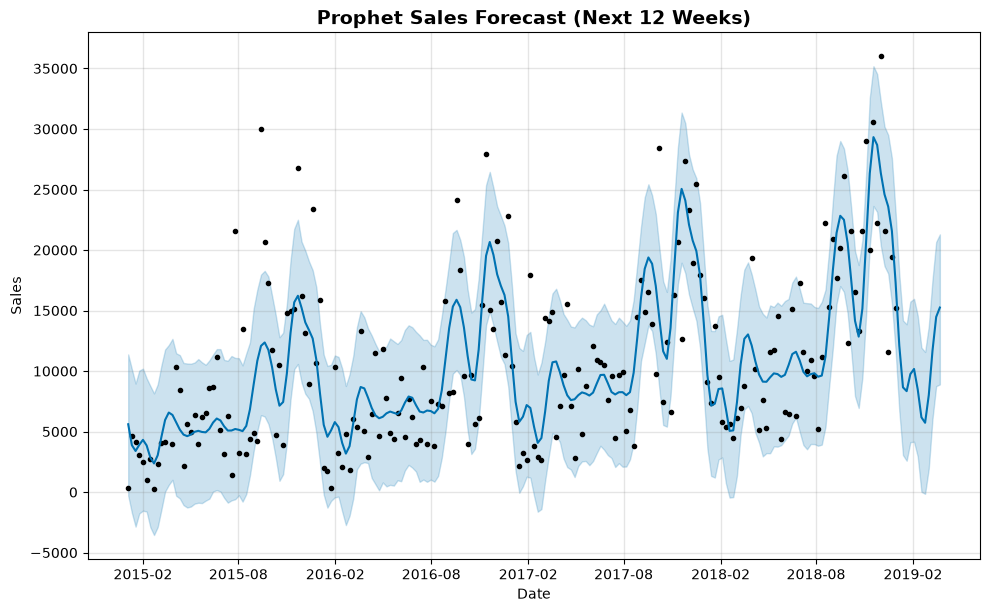

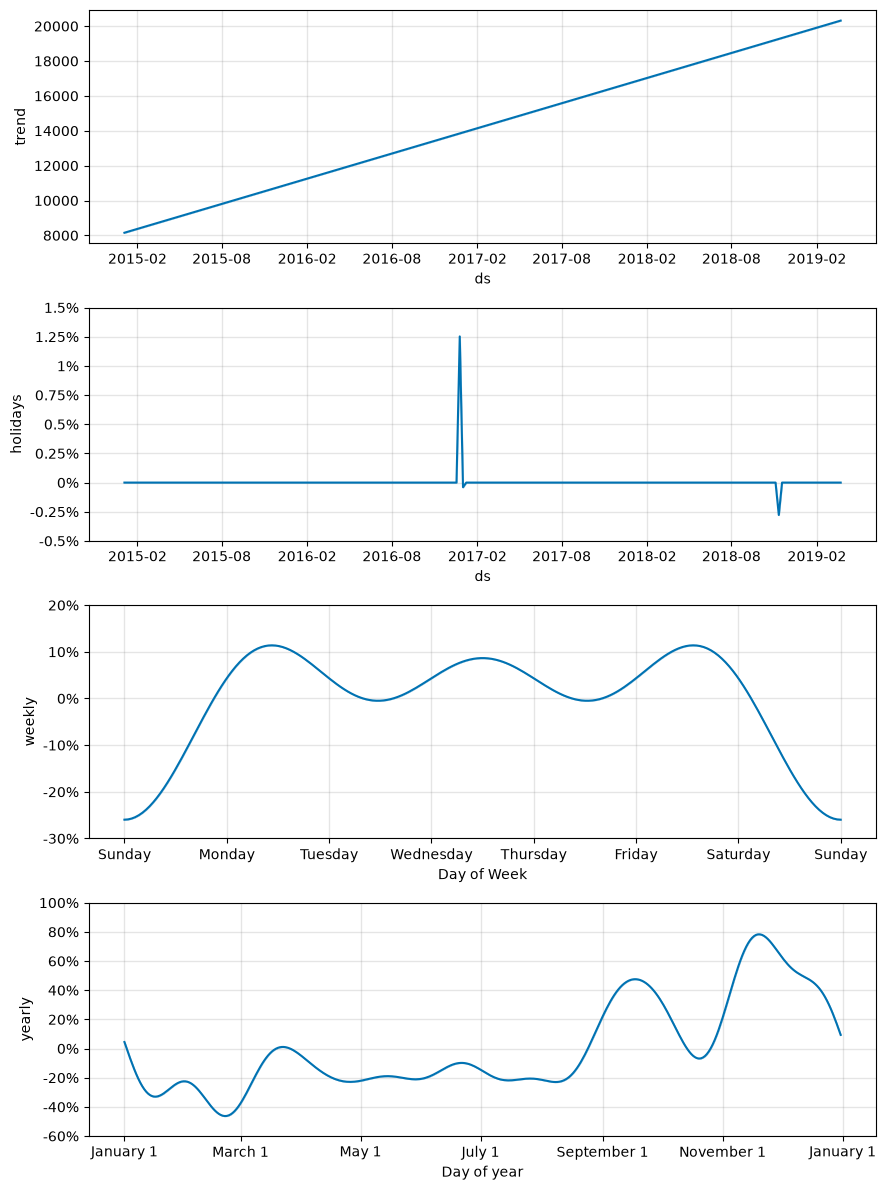

In [32]:
fb_prophet_model = Prophet( seasonality_mode='multiplicative',
                      yearly_seasonality=True,           
                      weekly_seasonality=True,
                      daily_seasonality=False,
                      **best_params)
fb_prophet_model.add_country_holidays(country_name='US')
fb_prophet_model.fit(prophet_df)
# Create a dataframe to hold the future dates (12 weeks out)
future = fb_prophet_model.make_future_dataframe(periods=12, freq='W')

forecast = fb_prophet_model.predict(future)

# Plotting the overall forecast
fig1 = fb_prophet_model.plot(forecast)
plt.title('Prophet Sales Forecast (Next 12 Weeks)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# Plotting the individual components (Trend, Weekly, Yearly)
fig2 = fb_prophet_model.plot_components(forecast)
plt.show()

#### XGboost

In [27]:
# ML models are time blind
ml_df = monthly_sales.copy()

# Create Lag Features (Shifting sales data down by 1, 2, and 3 periods)
ml_df['Lag_1'] = ml_df['Sales'].shift(1)
ml_df['Lag_2'] = ml_df['Sales'].shift(2)
ml_df['Lag_3'] = ml_df['Sales'].shift(3)

# Create Rolling Mean (3-month window of the lags to avoid data leakage)
# We calculate the rolling mean on the shifted data so the model doesn't peak at current sales
ml_df['Rolling_Mean_3'] = ml_df['Lag_1'].rolling(window=3).mean()

# Extract Date Features
ml_df['Month'] = ml_df.index.month
ml_df['Quarter'] = ml_df.index.quarter

# Map Season to numeric values for XGBoost (Winter: 1, Spring: 2, Summer: 3, Fall: 4)
def get_numeric_season(month):
    if month in [12, 1, 2]: return 1
    elif month in [3, 4, 5]: return 2
    elif month in [6, 7, 8]: return 3
    else: return 4
ml_df['Season_Num'] = ml_df['Month'].apply(get_numeric_season)

# Shifting data creates empty rows at the beginning of the dataset
ml_df.dropna(inplace=True)

print("Supervised ML DataFrame Head:")
print(ml_df.head())

Supervised ML DataFrame Head:
            index       Sales       Lag_1       Lag_2      Lag_3  \
Order Date                                                         
2015-04-30      3  27906.8550  55205.7970   4519.8920  14205.707   
2015-05-31      4  23644.3030  27906.8550  55205.7970   4519.892   
2015-06-30      5  34322.9356  23644.3030  27906.8550  55205.797   
2015-07-31      6  33781.5430  34322.9356  23644.3030  27906.855   
2015-08-31      7  27117.5365  33781.5430  34322.9356  23644.303   

            Rolling_Mean_3  Month  Quarter  Season_Num  
Order Date                                              
2015-04-30    24643.798667      4        2           2  
2015-05-31    29210.848000      5        2           2  
2015-06-30    35585.651667      6        2           3  
2015-07-31    28624.697867      7        3           3  
2015-08-31    30582.927200      8        3           3  


In [28]:
import xgboost as xgb
# Define Features (X) and Target (y)
features = ['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month', 'Quarter', 'Season_Num']
X = ml_df[features]
y = ml_df['Sales']

# Initialize and fit the XGBoost Regressor
# n_estimators=100 and learning_rate=0.1 are standard, stable starting points
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X, y)

print("XGBoost Model successfully trained.")

XGBoost Model successfully trained.


In [29]:
# Create a list to store our future predictions
future_predictions = []

# Get the very last row of our known data to use as the starting point
current_lags = ml_df['Sales'].iloc[-3:].values.tolist() # [Lag_3, Lag_2, Lag_1]

# Define the next 3 future dates
last_date = ml_df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='ME')

for date in future_dates:
    # 1. Construct the feature row for the current target month
    lag_1 = current_lags[-1]
    lag_2 = current_lags[-2]
    lag_3 = current_lags[-3]
    rolling_3 = np.mean([lag_1, lag_2, lag_3])
    month = date.month
    quarter = date.quarter
    season = get_numeric_season(month)
    
    # Format into a DataFrame to match training columns
    X_future = pd.DataFrame([[lag_1, lag_2, lag_3, rolling_3, month, quarter, season]], columns=features)
    
    # 2. Make the prediction
    pred = xgb_model.predict(X_future)[0]
    future_predictions.append(pred)
    
    # 3. Update the lags for the NEXT iteration
    # The current prediction becomes the new Lag_1 for the next loop
    current_lags.append(pred)

# Combine dates and predictions into a clean DataFrame
xgb_forecast = pd.Series(future_predictions, index=future_dates)
print("\nXGBoost 3-Month Forecast:\n", xgb_forecast, sep="")


XGBoost 3-Month Forecast:
2019-01-31    43391.343750
2019-02-28    21705.279297
2019-03-31    54398.324219
Freq: ME, dtype: float32


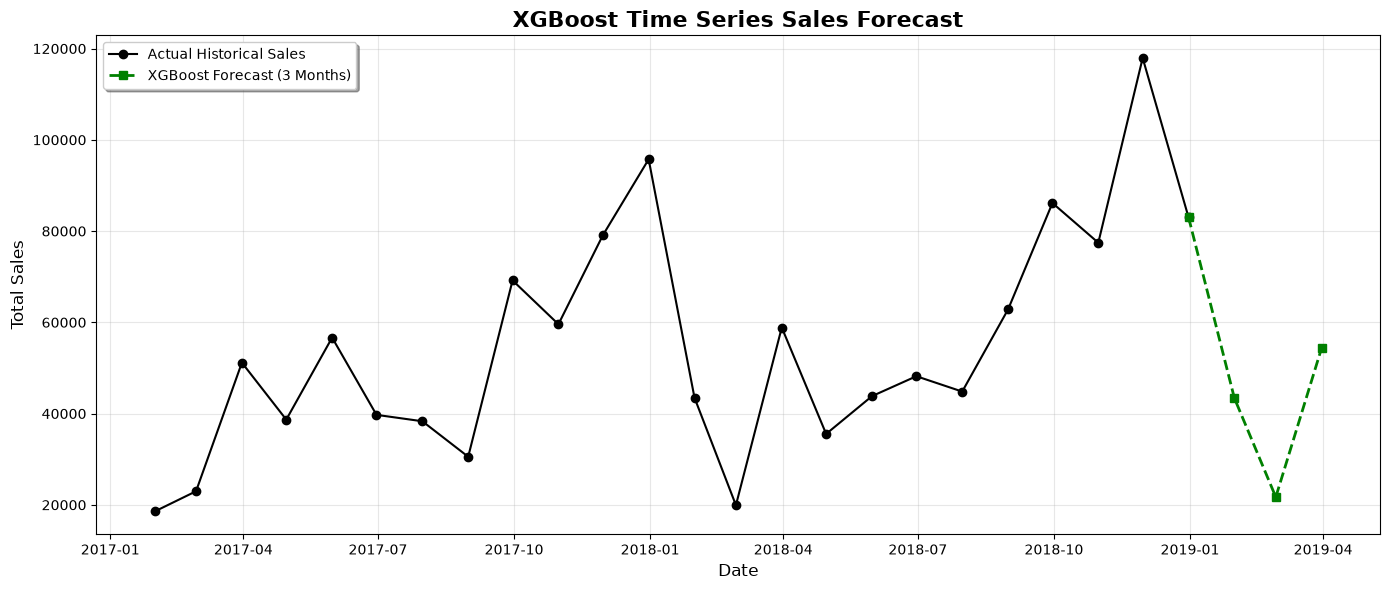

In [31]:
plt.figure(figsize=(14, 6))

# Plot the last 2 years of actual historical sales for context
history_to_plot = monthly_sales['Sales'].iloc[-24:]
plt.plot(history_to_plot.index, history_to_plot, label='Actual Historical Sales', color='black', marker='o')

# Plot the XGBoost Forecast
# We connect the line by starting the plot array with the last known historical value
plot_idx = [history_to_plot.index[-1]] + list(xgb_forecast.index)
plot_vals = [history_to_plot.iloc[-1]] + list(xgb_forecast.values)

plt.plot(plot_idx, plot_vals, label='XGBoost Forecast (3 Months)', color='green', linestyle='--', marker='s', linewidth=2)

# Formatting
plt.title('XGBoost Time Series Sales Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Model Comparision

In [37]:
# Function to compute and return MAE, RMSE, and MAPE
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)*100
    return round(mae, 2), round(rmse, 2), round(mape, 4)

# Training history and actual sales for the last 3 months
forecast_steps = 3
train_history = monthly_sales.iloc[:-forecast_steps]
actual_sales = monthly_sales['Sales'].iloc[-forecast_steps:].values
forecast_dates = monthly_sales.index[-forecast_steps:]

# SARIMA Metrics
sarima_fit = pm.auto_arima(
    train_history['Sales'],
    seasonal=True,
    m=12,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    D=1,
    trace=False, # Set to False inside the loop to avoid cluttering logs
    error_action='ignore',
    # suppress_warnings=True,
    stepwise=True
)
sarima_preds = sarima_fit.predict(n_periods=forecast_steps)

# FB Prophet Metrics
prophet_train = prophet_df.iloc[:-(forecast_steps*4)]  # Using weekly data, so multiply by 4 for weeks in a month
actual_prophet = prophet_df['y'].iloc[-(forecast_steps*4):].values
forecast_dates_prophet = prophet_df['ds'].iloc[-(forecast_steps*4):]

fb_prophet_fit = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    **best_params
)
fb_prophet_fit.add_country_holidays(country_name='US')
fb_prophet_fit.fit(prophet_train)
future_val = fb_prophet_fit.make_future_dataframe(periods=forecast_steps, freq='W') 
forecast_val = fb_prophet_fit.predict(future_val)
prophet_validation_preds = forecast_val['yhat'].iloc[-(forecast_steps*4):].values


14:03:03 - cmdstanpy - INFO - Chain [1] start processing
14:03:04 - cmdstanpy - INFO - Chain [1] done processing


In [38]:
# XGBoost Metrics
ml_train = ml_df.iloc[:-forecast_steps]
X_train = ml_train[features] # Using already defined features list
y_train = ml_train['Sales']
xgb_model.fit(X_train, y_train) # Using the same model instance to avoid re-initialization
xgb_preds = []
# Start with the last known row of your training history to extract time features
current_row = ml_train.iloc[-1].copy() 
for step in range(forecast_steps):
    # Dynamically build the feature vector for this step
    # Update lags based on previous step's forecast (if not the first step)
    if step > 0:
        current_row['Lag_3'] = current_row['Lag_2']
        current_row['Lag_2'] = current_row['Lag_1']
        current_row['Lag_1'] = xgb_preds[-1]
        current_row['Rolling_Mean_3'] = np.mean([current_row['Lag_1'], current_row['Lag_2'], current_row['Lag_3']])
    
    # Update calendar features based on the validation target row
    target_row = ml_df.iloc[-forecast_steps + step]
    current_row['Month'] = target_row['Month']
    current_row['Quarter'] = target_row['Quarter']
    current_row['Season_Num'] = target_row['Season_Num']
    
    # Predict 1 step ahead
    X_pred = pd.DataFrame([current_row[features]])
    pred = xgb_model.predict(X_pred)[0]
    xgb_preds.append(pred)

xgb_validation_preds = np.array(xgb_preds)

In [61]:
# Compile all metrics into a DataFrame for comparison
sarima_metrics = get_metrics(actual_sales, sarima_preds)
prophet_metrics = get_metrics(actual_prophet, prophet_validation_preds)
xgb_metrics = get_metrics(actual_sales, xgb_validation_preds)

last_historical_date = prophet_df['ds'].max()
future_sales_df = forecast[forecast['ds'] > last_historical_date].copy()
prophet_monthly_forecast = tuple(future_sales_df['yhat'])
prophet_monthly_forecast = (
    sum(prophet_monthly_forecast[0:4]),   # Month 1 (Weeks 1 to 4)
    sum(prophet_monthly_forecast[4:8]),   # Month 2 (Weeks 5 to 8)
    sum(prophet_monthly_forecast[8:12])   # Month 3 (Weeks 9 to 12)
)

metrics_summary = pd.DataFrame({
    'Model': ['SARIMA', 'FB Prophet', 'XGBoost'],
    'MAE': [
        sarima_metrics[0],
        prophet_metrics[0],
        xgb_metrics[0]
    ],
    'RMSE': [
        sarima_metrics[1],
        prophet_metrics[1],
        xgb_metrics[1]
    ],
    'MAPE (%)': [
        sarima_metrics[2],
        prophet_metrics[2],
        xgb_metrics[2]
    ],
    'Forecast for Month 1': [
        sarima_forecast.to_numpy()[0].__round__(2),
        prophet_monthly_forecast[0].__round__(2),
        xgb_forecast.to_numpy()[0].__round__(2)
    ],
    'Forecast for Month 2': [
        sarima_forecast.to_numpy()[1].__round__(2),
        prophet_monthly_forecast[1].__round__(2),
        xgb_forecast.to_numpy()[1].__round__(2)
    ],
    'Forecast for Month 3': [
        sarima_forecast.to_numpy()[2].__round__(2),
        prophet_monthly_forecast[2].__round__(2),
        xgb_forecast.to_numpy()[2].__round__(2)
    ]
})

In [62]:
metrics_summary

,Model,MAE,RMSE,MAPE (%),Forecast for Month 1,Forecast for Month 2,Forecast for Month 3
0,SARIMA,20740.75,21492.82,22.0356,49686.020000,36069.710000,70458.340000
1,FB Prophet,5066.04,6229.63,22.5413,38865.410000,30570.920000,49419.610000
2,XGBoost,27184.18,39961.36,24.8441,43391.339844,21705.279297,54398.320312


Superstore requires reliable foresight to manage supply chain logistics, minimizing extreme variance (RMSE) while maintaining a tight baseline accuracy (MAPE) makes **FB Prophet** the mathematically optimal choice.

## Category & Region level Forecasting

In [ ]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

def generate_segment_forecast(df, filter_column, filter_value, periods=12):
    """
    Filters the dataset, prepares it for Prophet, trains the model, and generates a forecast.
    """
    # Filter the data for the specific segment (e.g., Category == 'Furniture')
    segment_data = df[df[filter_column] == filter_value].copy()
    
    # Aggregate into weekly sales to match our best Prophet architecture
    segment_data = segment_data.set_index('Order Date')
    weekly_segment = segment_data['Sales'].resample('W').sum().reset_index()
    
    # Format for Prophet
    weekly_segment.columns = ['ds', 'y']
    
    # Initialize and train the winning Prophet model
    m = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=1.0
    )
    m.add_country_holidays(country_name='US')
    m.fit(weekly_segment)
    
    # Predict the future (3 months)
    future = m.make_future_dataframe(periods=periods, freq='W')
    forecast = m.predict(future)
    
    # Return both the model and the forecast dataframe
    return m, forecast

In [ ]:
# Define the 5 specific segments to forecast
segments_to_forecast = [
    ('Category', 'Furniture'),
    ('Category', 'Technology'),
    ('Category', 'Office Supplies'),
    ('Region', 'West'),
    ('Region', 'East')
]

# Dictionary to store the future predictions for plotting
all_forecasts = {}

print("Training Prophet models for all 5 segments...")

for column, value in segments_to_forecast:
    # Run our pipeline function using the copied sales data in EDA
    model, forecast_df = generate_segment_forecast(df, column, value, periods=12)
    
    # Store the predicted values ('yhat') and dates ('ds')
    # We only need the future projection dates (the last 12 rows)
    future_only = forecast_df[['ds', 'yhat']].tail(12)
    
    # Save to dictionary using the segment name as the key
    all_forecasts[value] = future_only

print("All models trained and forecasted successfully.")

Training Prophet models for all 5 segments...
All models trained and forecasted successfully.


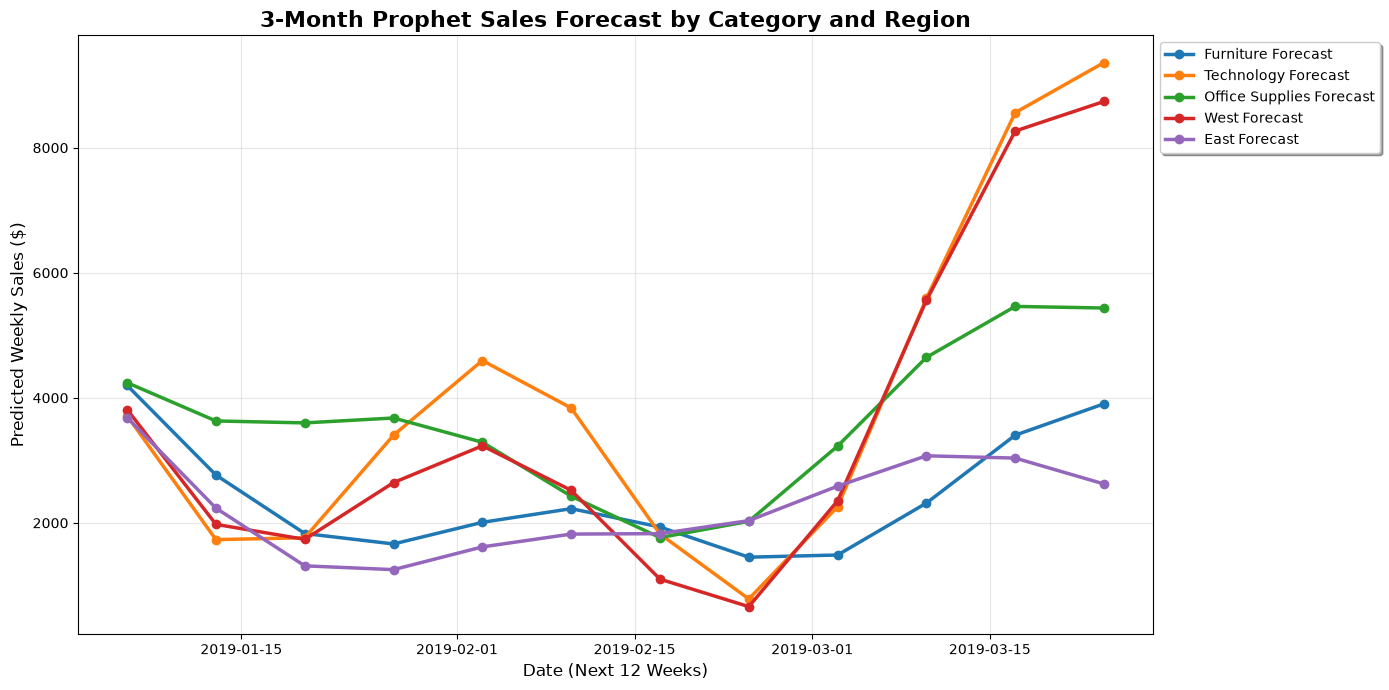

In [71]:
plt.figure(figsize=(14, 7))

# Loop through our stored forecasts and plot them
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for (segment_name, forecast_data), color in zip(all_forecasts.items(), colors):
    plt.plot(
        forecast_data['ds'], 
        forecast_data['yhat'], 
        label=f"{segment_name} Forecast", 
        linewidth=2.5, 
        marker='o',
        color=color
    )

# Professional Formatting
plt.title('3-Month Prophet Sales Forecast by Category and Region', fontsize=16, fontweight='bold')
plt.xlabel('Date (Next 12 Weeks)', fontsize=12)
plt.ylabel('Predicted Weekly Sales ($)', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout() # Ensures the legend doesn't get cut off
plt.show()

In [74]:
print("Forecasted Growth Analysis (Next 3 Months)")

for segment_name, forecast_data in all_forecasts.items():
    # Get the first and last predicted weekly sales values in our 12-week window
    start_value = forecast_data['yhat'].iloc[0]
    end_value = forecast_data['yhat'].iloc[-1]
    
    # Calculate percentage change
    growth_pct = ((end_value - start_value) / start_value) * 100
    
    print(f"{segment_name:15}: {growth_pct:+.2f}% predicted growth")

Forecasted Growth Analysis (Next 3 Months)
Furniture      : -7.00% predicted growth
Technology     : +152.17% predicted growth
Office Supplies: +28.16% predicted growth
West           : +129.25% predicted growth
East           : -28.83% predicted growth


It is clear that Technology category and the West region is showing the strongest growth

## Anomaly Detection

In [75]:
# Using Isolation Forest
from sklearn.ensemble import IsolationForest
df_anom = weekly_sales.copy()
# 'contamination' is the expected percentage of outliers. I choose 5% as it is a standard starting point.
iso_forest = IsolationForest(contamination=0.05, random_state=42)

df_anom['IF_Label'] = iso_forest.fit_predict(df_anom[['Sales']])
# -1 indicates an anomaly, 1 indicates normal
df_anom['Anomaly_IF'] = df_anom['IF_Label'] == -1

In [82]:
# Using Z score based detection
# Define a window size
window_size = 4 # 1 month of local context

# Calculate rolling metrics
df_anom['Rolling_Mean'] = df_anom['Sales'].shift(1).rolling(window=window_size).mean()
df_anom['Rolling_Std'] = df_anom['Sales'].shift(1).rolling(window=window_size).std()

# Calculate the Z-Score
df_anom['Z_Score'] = (df_anom['Sales'] - df_anom['Rolling_Mean']) / df_anom['Rolling_Std']

# Flag anomalies where the absolute Z-Score is greater than 2
# I use absolute because sales can be unusually high (+) or unusually low (-)
df_anom['Anomaly_Z'] = df_anom['Z_Score'].abs() > 2

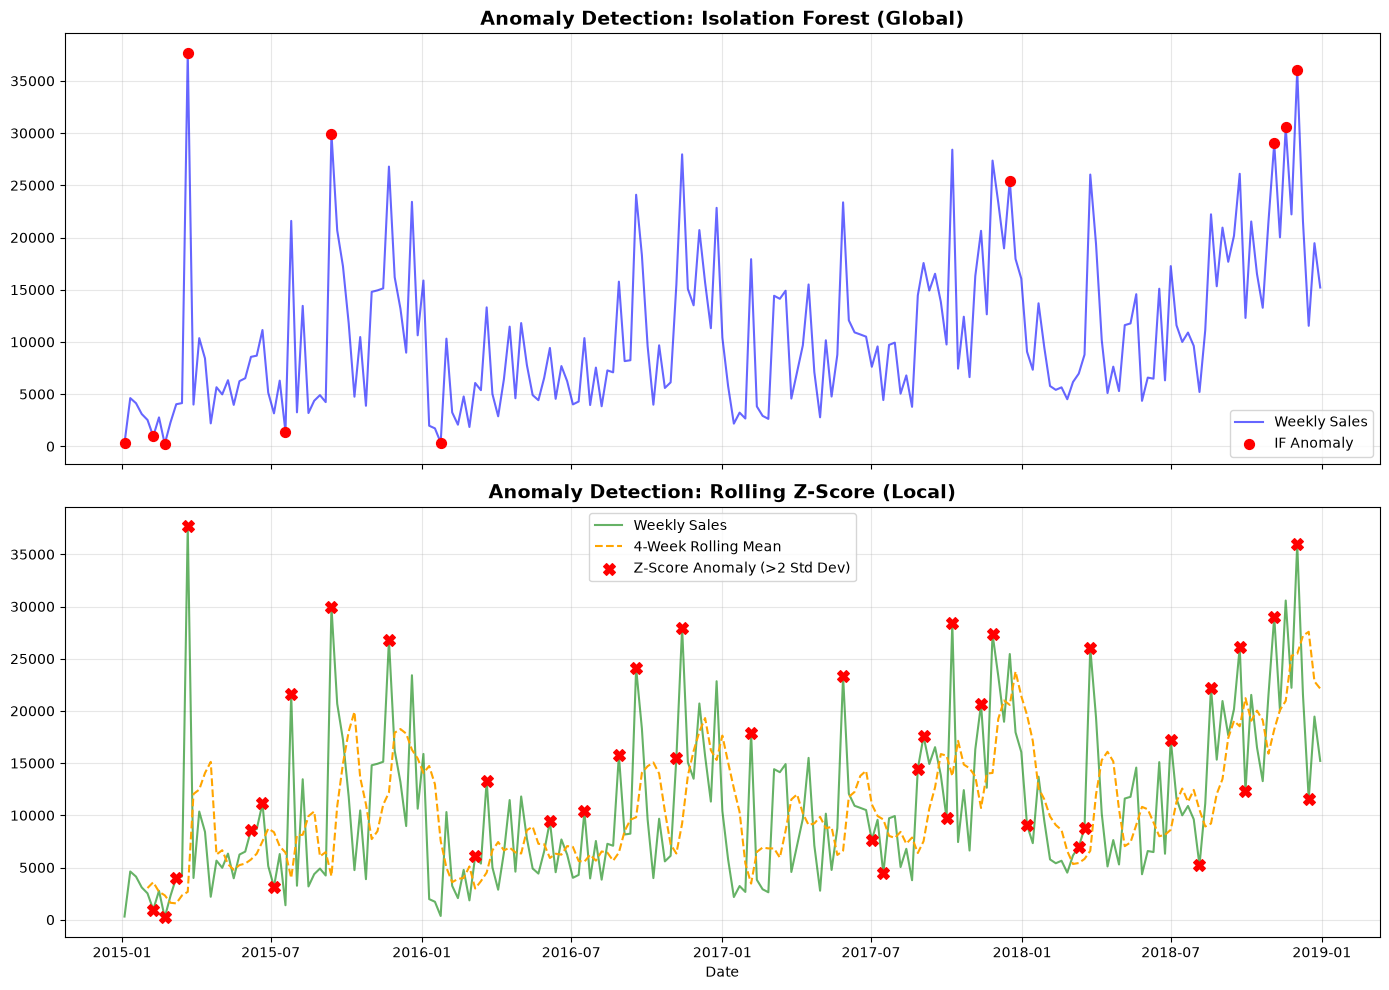

In [83]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Isolation Forest
ax1.plot(df_anom['Order Date'], df_anom['Sales'], color='blue', alpha=0.6, label='Weekly Sales')
# Extract and plot the anomalies
if_anomalies = df_anom[df_anom['Anomaly_IF']]
ax1.scatter(if_anomalies['Order Date'], if_anomalies['Sales'], color='red', s=50, label='IF Anomaly', zorder=5)
ax1.set_title('Anomaly Detection: Isolation Forest (Global)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Rolling Z-Score
ax2.plot(df_anom['Order Date'], df_anom['Sales'], color='green', alpha=0.6, label='Weekly Sales')
ax2.plot(df_anom['Order Date'], df_anom['Rolling_Mean'], color='orange', linestyle='--', label='4-Week Rolling Mean')
# Extract and plot the anomalies
z_anomalies = df_anom[df_anom['Anomaly_Z']]
ax2.scatter(z_anomalies['Order Date'], z_anomalies['Sales'], color='red', marker='X', s=70, label='Z-Score Anomaly (>2 Std Dev)', zorder=5)
ax2.set_title('Anomaly Detection: Rolling Z-Score (Local)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observations for Isolation Forest**
- Early 2015 Near zero drops: This likely represents initial system deployment or data migration
- Early 2015 Extreme spike (~37,500): This indicates a massive initial product launch or grand opening event.
-  Mid 2015 Near-Zero Drop This points to a severe platform outage or supply chain freeze.
-  Late 2015 High Spike (~30,000): This corresponds to the holiday shopping season kickoff.
- Early 2016 Near-Zero Drop: This represents a post-holiday operational pause. Many businesses experience a complete freeze in transactions during the first week of January due to annual inventory audits, warehouse maintenance, or system resets.
- Late 2017 High Spike (~25,000): This indicates a highly successful year-end festive promotion.
- Late 2018 Consecutive Extreme Spikes: This suggests unprecedented business scaling or viral demand.

**The two methods largely disagree**
-  Both methods agree on the absolute highest peaks (like early 2015 and late 2018) and the lowest drops to zero.
- Rolling Z-Score flags dozens of anomalies(The Local Nuances) that Isolation Forest completely ignores.
- It clearly tells us that Isolation Forest Looks at the "Big Picture"(Global Scope), while Rolling Z-Score Looks at the "Context" (Local Scope).
-  Isolation forest ignores steady business growth. A sales week of 25,000 in late 2018 looks totally normal to it because 25,000 is a common volume for 2018.
-  Rolling Z Score ignores steady business growth. A sales week of 25,000 in late 2018 looks totally normal to Isolation Forest because 25,000 is a common volume for 2018.
- So in conclusion, Isolation Forest can be used for detecting anomalies globally, while rolling Z-score is  much better for detecting short-term operational surprises (like a single bad shipping week or a flash sale), regardless of whether the business is growing or shrinking.

## Product Demand Segmentation

In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Total Sales Volume
total_sales = df.groupby('Sub-Category')['Sales'].sum().rename('Total_Sales')
# Average Order Value (AOV)
aov = df.groupby('Sub-Category')['Sales'].mean().rename('Average_Order_Value')

# Sales Volatility (Standard deviation of monthly sales)
# First, get monthly sales per sub-category
monthly_sub_sales = df.groupby(['Sub-Category', 'Year', 'Month'])['Sales'].sum().reset_index()
volatility = monthly_sub_sales.groupby('Sub-Category')['Sales'].std().rename('Volatility')

# Sales Growth Rate (YoY Approximation)
# Get total sales for the first year and the last year in the dataset
yearly_sub_sales = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()
first_year = yearly_sub_sales.columns.min()
last_year = yearly_sub_sales.columns.max()

# Calculate percentage growth from first year to last year
growth_rate = ((yearly_sub_sales[last_year] - yearly_sub_sales[first_year]) / yearly_sub_sales[first_year]).rename('Growth_Rate')

# Combine all features into one clustering DataFrame
cluster_df = pd.concat([total_sales, aov, volatility, growth_rate], axis=1)

print("Engineered Features Head:")
print(cluster_df.head())

Engineered Features Head:
              Total_Sales  Average_Order_Value   Volatility  Growth_Rate
Sub-Category                                                            
Accessories   164186.7000           217.178175  2579.994809     1.450560
Appliances    104618.4030           227.926804  1821.621539     1.652429
Art            26705.4100            34.019631   330.488343     0.496495
Binders       200028.7850           134.067550  3848.223648     0.657786
Bookcases     113813.1987           503.598224  2220.405080     0.498466


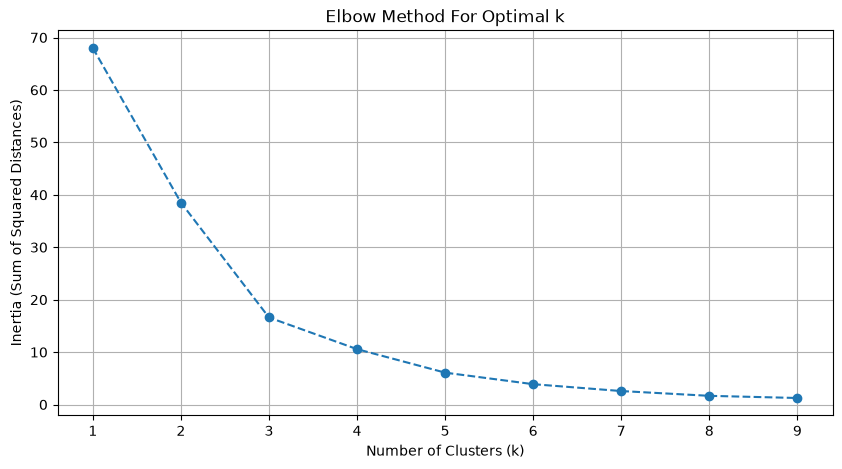

In [ ]:
# Scale the data since Distance-based algorithms like K-Means are 
# highly sensitive to the scale of the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

# The Elbow Method to find optimal 'k'
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(K, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.show()

Variance captured by 2D PCA projection: 89.98%


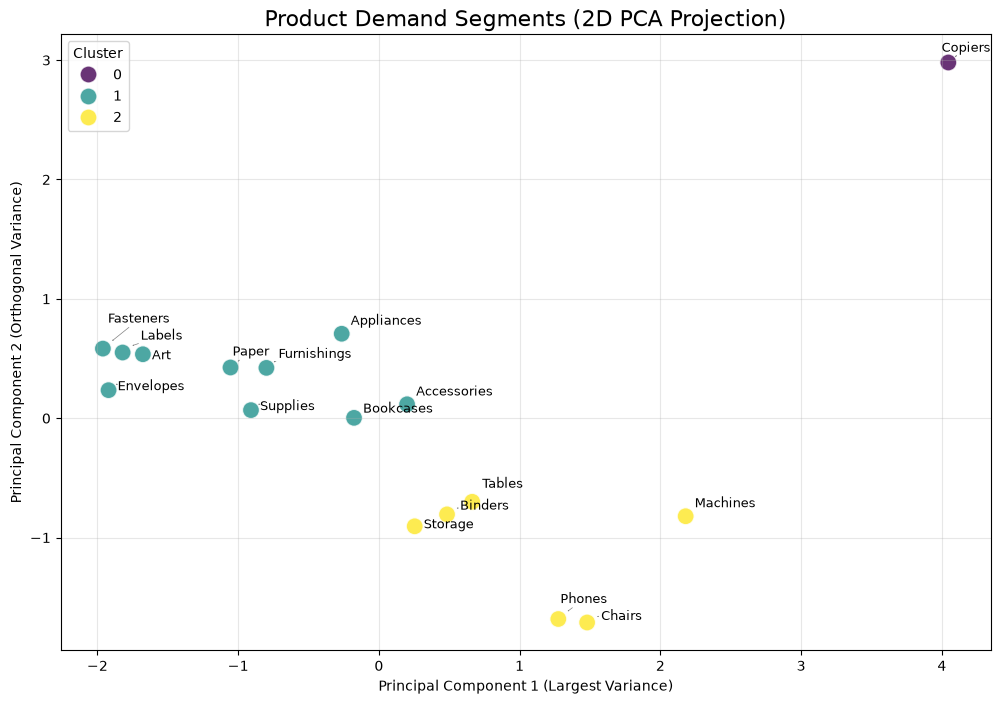

In [93]:
from adjustText import adjust_text
# Apply K-Means
optimal_k = 3 # From the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Apply PCA for 2D Visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Add the 2D coordinates back to our dataframe for plotting
cluster_df['PCA1'] = principal_components[:, 0]
cluster_df['PCA2'] = principal_components[:, 1]

# Print the variance ratio to see how much information we retained
explained_variance = pca.explained_variance_ratio_.sum() * 100
print(f"Variance captured by 2D PCA projection: {explained_variance:.2f}%")
cluster_labels = {
    0: "High-Volume Outliers (Copiers)",
    1: "Small Office Supplies & Consumables",
    2: "Furniture & Major Tech Equipment"
}
cluster_df['Cluster Name'] = cluster_df['Cluster'].map(cluster_labels)
# Plot the Clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Cluster', 
    data=cluster_df, 
    palette='viridis', 
    s=150, 
    alpha=0.8
)
texts = []
# Add sub-category labels to the points
for i in range(cluster_df.shape[0]):
    t = plt.text(
        cluster_df['PCA1'].iloc[i] + 0.05, 
        cluster_df['PCA2'].iloc[i] + 0.05, 
        cluster_df.index[i], 
        fontsize=9
    )
    texts.append(t)
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

plt.title('Product Demand Segments (2D PCA Projection)', fontsize=16)
plt.xlabel('Principal Component 1 (Largest Variance)')
plt.ylabel('Principal Component 2 (Orthogonal Variance)')
plt.grid(True, alpha=0.3)
plt.show()

In [88]:
# Calculate the mean of our original features for each cluster
cluster_profiles = cluster_df.groupby('Cluster')[['Total_Sales', 'Average_Order_Value', 'Volatility', 'Growth_Rate']].mean()
print(cluster_profiles)

           Total_Sales  Average_Order_Value   Volatility  Growth_Rate
Cluster                                                              
0        239495.780667           361.131228  3489.056075     0.564652
1        146248.094000          2215.880212  5500.774391     4.797295
2         54341.708189           142.746758  1031.431565     0.587958
3        189238.631000          1645.553313  5603.554747    -0.297931


**Stocking Strategy for each Cluster**
- Cluster 0: Extreme Growth, High Value
  - This cluster is exploding in demand and carries a massive price tag per order. However, the high volatility means demand spikes are erratic.
  - I would recommend not to allow these to stock out. Beacause missing a single order costs thousands of dollars. Also Increase safety stock levels and continuously re-train the short-term forecasting models (like the Prophet model built earlier) strictly on this segment to catch sudden demand surges early.
- Cluster 1: Low Volume, Low Volatility
  - These items are cheap, highly predictable, and do not drive our bottom line. We do not want our supply chain team wasting time managing them daily.
  - My recommendation is to order these in large bulk quantities on a set periodic schedule (e.g., once a quarter) to minimize shipping and administrative costs.
- Cluster 2: Continuous Replenishment(High Volume, Moderate Growth)
  - Because these items drive the bulk of our consistent revenue and have moderate volatility, they are highly predictable.
  - It is better to implement automated reordering with tight safety stock thresholds. The goal is to maintain a near 100% service level (never stock out) while keeping warehouse holding costs as lean as possible, as these items turn over quickly.